In [13]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import random
import seaborn as sns
import numpy as np
from scipy.stats import multivariate_normal

sns.set_style("whitegrid")


# 1

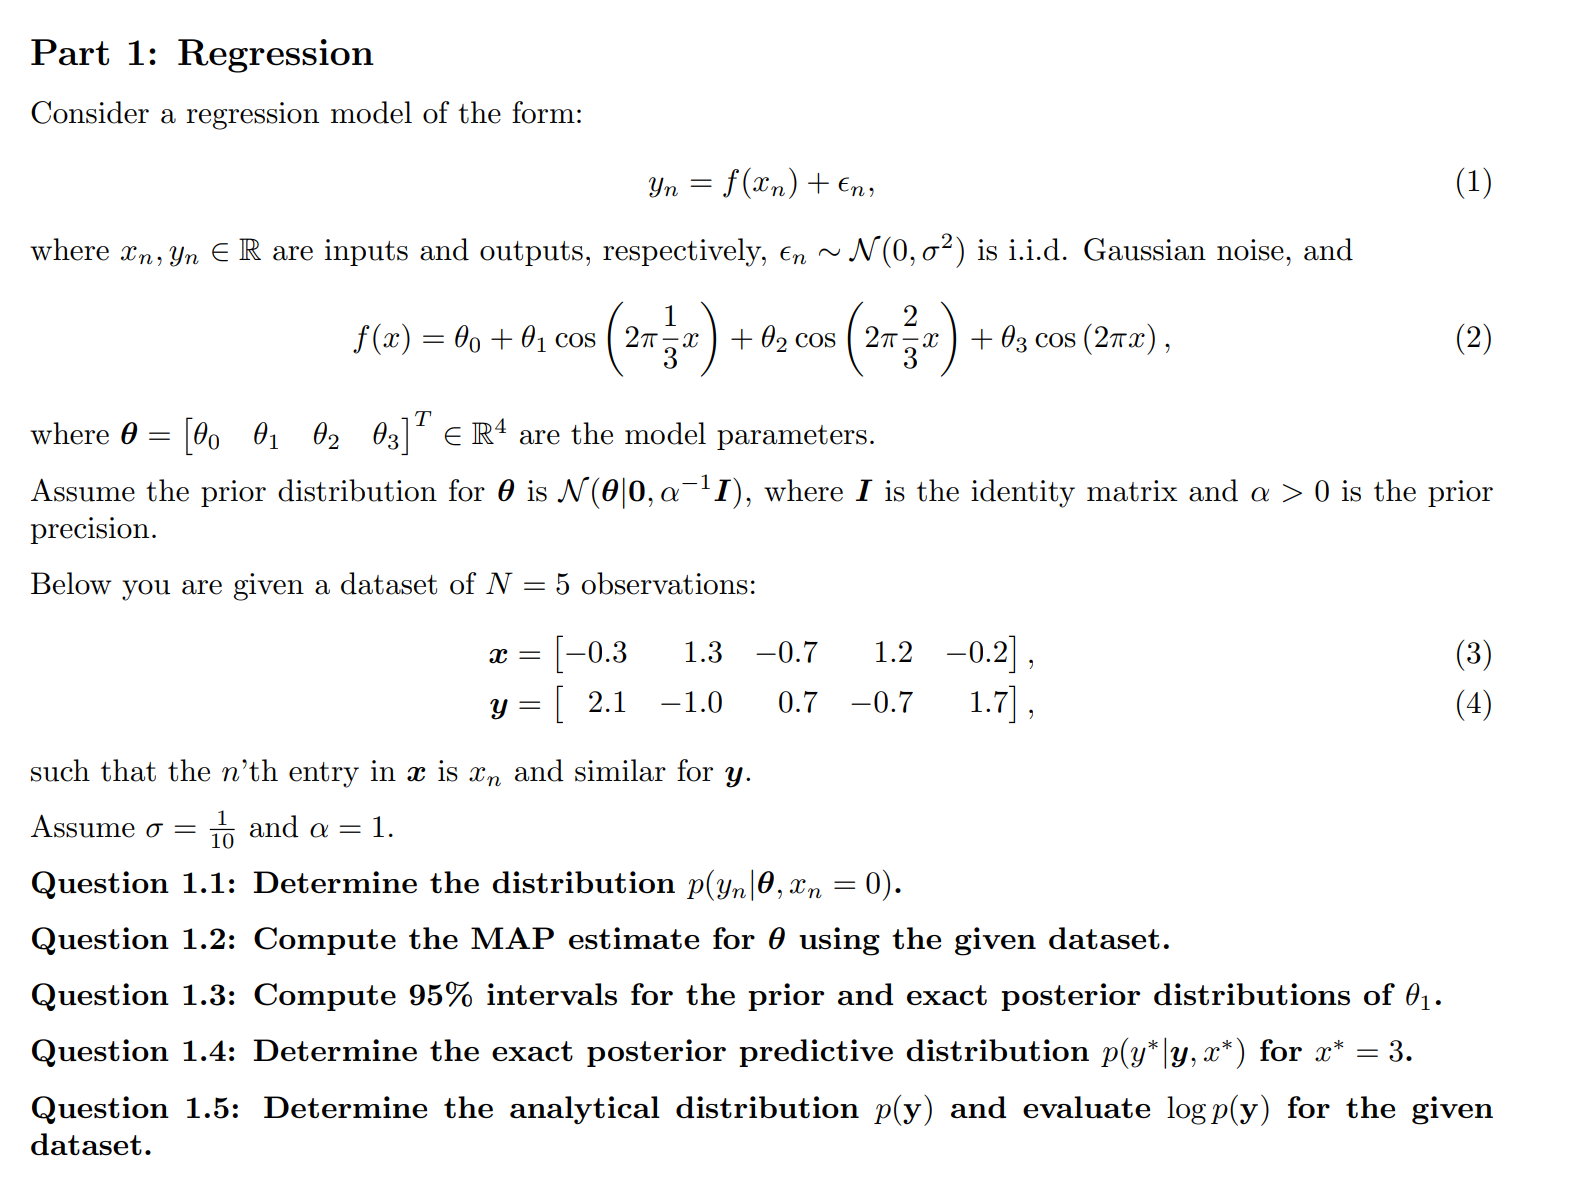

## 1.1

See paper hand-in

## 1.2

In [9]:
xtrain = jnp.array(
    [
        -0.3,
        1.3,
        -0.7,
        1.2,
        -0.2,
    ]
)
ytrain = jnp.array(
    [
        2.1,
        -1.0,
        0.7,
        -0.7,
        1.7,
    ]
)

sigma = 1 / 10
sigma_sq = sigma**2
alpha = 1

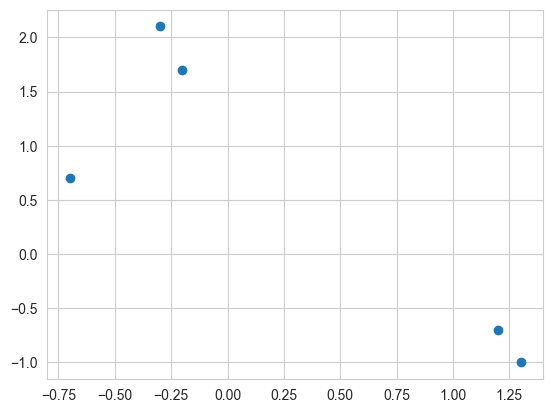

In [10]:
plt.scatter(xtrain, ytrain)

Phi_train=Array([[ 1.        ,  0.809017  ,  0.30901697, -0.30901715],
       [ 1.        , -0.9135455 ,  0.66913074, -0.30901653],
       [ 1.        ,  0.10452842, -0.9781476 , -0.3090171 ],
       [ 1.        , -0.80901706,  0.30901712,  0.30901635],
       [ 1.        ,  0.9135454 ,  0.66913056,  0.30901697]],      dtype=float32)


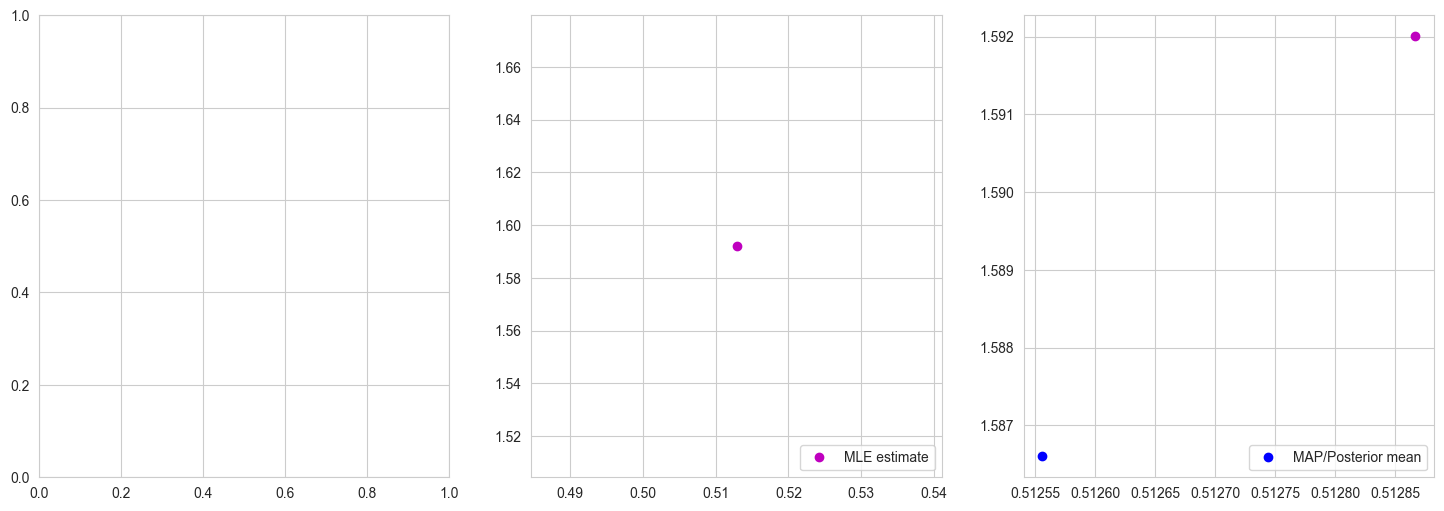

In [ ]:
## From ex3
pi = jnp.pi
cos = jnp.cos

# hyperparameters
beta = 1 / sigma_sq


# log normal probability density function
log_npdf = lambda x, m, v: -0.5 * jnp.log(2 * jnp.pi * v) - 0.5 * (x - m) ** 2 / v


def f(x, theta):
    # Bad form to have this twice, but under time pressure
    coeff1 = 2 * pi * (1 / 3)
    coeff2 = 2 * pi * (2 / 3)
    coeff3 = 2 * pi

    return (
        theta[0]
        + theta[1] * cos(coeff1 * x)
        + theta[2] * cos(coeff2 * x)
        + theta[3] * cos(coeff3 * x)
    )


# simple function for making predictions
predict = lambda x, theta: f(x, theta)


def log_prior(x, y, theta):
    return multivariate_normal.logpdf(
        theta, jnp.array([0, 0]), 1 / alpha * jnp.identity(2)
    )


def log_likelihood(x, y, theta):
    return jnp.sum(log_npdf(y, predict(x, theta), 1 / beta), 0)


def log_posterior(x, y, theta):
    return log_prior(x, y, theta) + log_likelihood(x, y, theta)


def design_matrix(x):
    coeff1 = 2 * pi * (1 / 3)
    coeff2 = 2 * pi * (2 / 3)
    coeff3 = 2 * pi

    return jnp.column_stack(
        [
            jnp.ones(len(x)),
            cos(coeff1 * x),
            cos(coeff2 * x),
            cos(coeff3 * x),
        ]
    )


# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# plot_distribution(
#     axes[0], xtrain, ytrain, density_fun=log_prior, color="b", title="Prior"
# )
# plot_distribution(
#     axes[1], xtrain, ytrain, density_fun=log_likelihood, color="r", title="Likelihood"
# )
# plot_distribution(
#     axes[2],
#     xtrain,
#     ytrain,
#     density_fun=log_prior,
#     color="b",
#     visibility=0.25,
#     label="Prior",
# )
# plot_distribution(
#     axes[2],
#     xtrain,
#     ytrain,
#     density_fun=log_likelihood,
#     color="r",
#     visibility=0.25,
#     label="Likelihood",
# )
# plot_distribution(
#     axes[2],
#     xtrain,
#     ytrain,
#     density_fun=log_posterior,
#     color="g",
#     label="Posterior",
#     title="Posterior",
# )

Phi_train = design_matrix(xtrain)
print(f"{Phi_train=}")

# compute maximum likelihood estimator for w
w_MLE = jnp.linalg.solve(Phi_train.T @ Phi_train, Phi_train.T @ ytrain).ravel()

# compute MAP/posterior mean
w_MAP = (
    beta
    * jnp.linalg.solve(
        alpha * jnp.identity(4) + beta * (Phi_train.T @ Phi_train), Phi_train.T
    )
    @ ytrain
).ravel()

# plot
axes[1].plot(w_MLE[0], w_MLE[1], "mo", label="MLE estimate")
axes[2].plot(w_MLE[0], w_MLE[1], "mo")
axes[2].plot(w_MAP[0], w_MAP[1], "bo", label="MAP/Posterior mean")

axes[1].legend(loc="lower right")
axes[2].legend(loc="lower right");


Answer to 1.2:

In [25]:
print(f"θ_MAP = {w_MAP}")

θ_MAP = [ 0.51255584  1.5866027  -0.01927561 -0.2754044 ]


## 1.3

See paper hand-in for math

In [48]:
from scipy import stats

# stats.Normal(mu=0, sigma=jnp.sqrt(alpha) ** (-1)).inter
theta1_p95_interval_prior = stats.norm.interval(
    1 - 0.95, loc=0, scale=jnp.sqrt(1 / alpha)
)
_ = theta1_p95_interval_prior
print(f"p(θ_1) 95% interval: [{_[0]:.3f}, {_[1]:.3f}]")

S = jnp.linalg.inv(alpha * jnp.identity(4) + beta * (Phi_train.T @ Phi_train))
# print(f"{S=}")
m = w_MAP

# Thus posterior for theta_1 is
var_theta1 = S[1, 1]
m_theta1 = m[1]
theta1_p95_interval_posterior = stats.norm.interval(
    1 - 0.95, loc=m_theta1, scale=jnp.sqrt(var_theta1)
)
_ = theta1_p95_interval_posterior
print(f"p(θ_1|y) 95% interval: [{_[0]:.3f}, {_[1]:.3f}]")


p(θ_1) 95% interval: [-0.063, 0.063]
p(θ_1|y) 95% interval: [1.583, 1.590]


In [49]:
# # Sanity check that scale is std and not var
# help(stats.norm)

## 1.4 Posterior Predictive

Recall: 
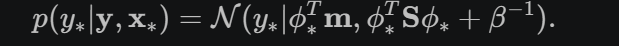

Text(0.5, 1.0, '$p(y_*|y, x_*)$')

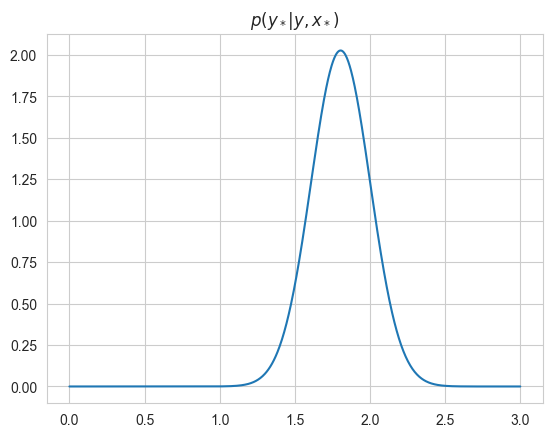

In [72]:
x_test = jnp.array([3])
Phi_test = design_matrix(x_test)

m_pred = m @ Phi_test.T
S_pred = Phi_test @ S @ Phi_test.T

loc = m_pred
scale = jnp.sqrt(S_pred + 1 / beta)
p = lambda y: stats.norm.pdf(y, loc=loc, scale=scale)

ys = jnp.linspace(-0, 3, 1000)
plt.plot(ys, p(ys)[0])
plt.title("$p(y_*|y, x_*)$")

## 1.5 Marginal Distribution

Recall:

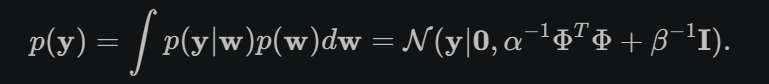

In [ ]:
mean = 0
cov = 1 / alpha * (Phi_train @ Phi_train.T) + 1 / beta * jnp.identity(5)
multivariate_normal.logpdf(ytrain, jnp.zeros(5), cov)

np.float64(-11.359573614717903)

# 2

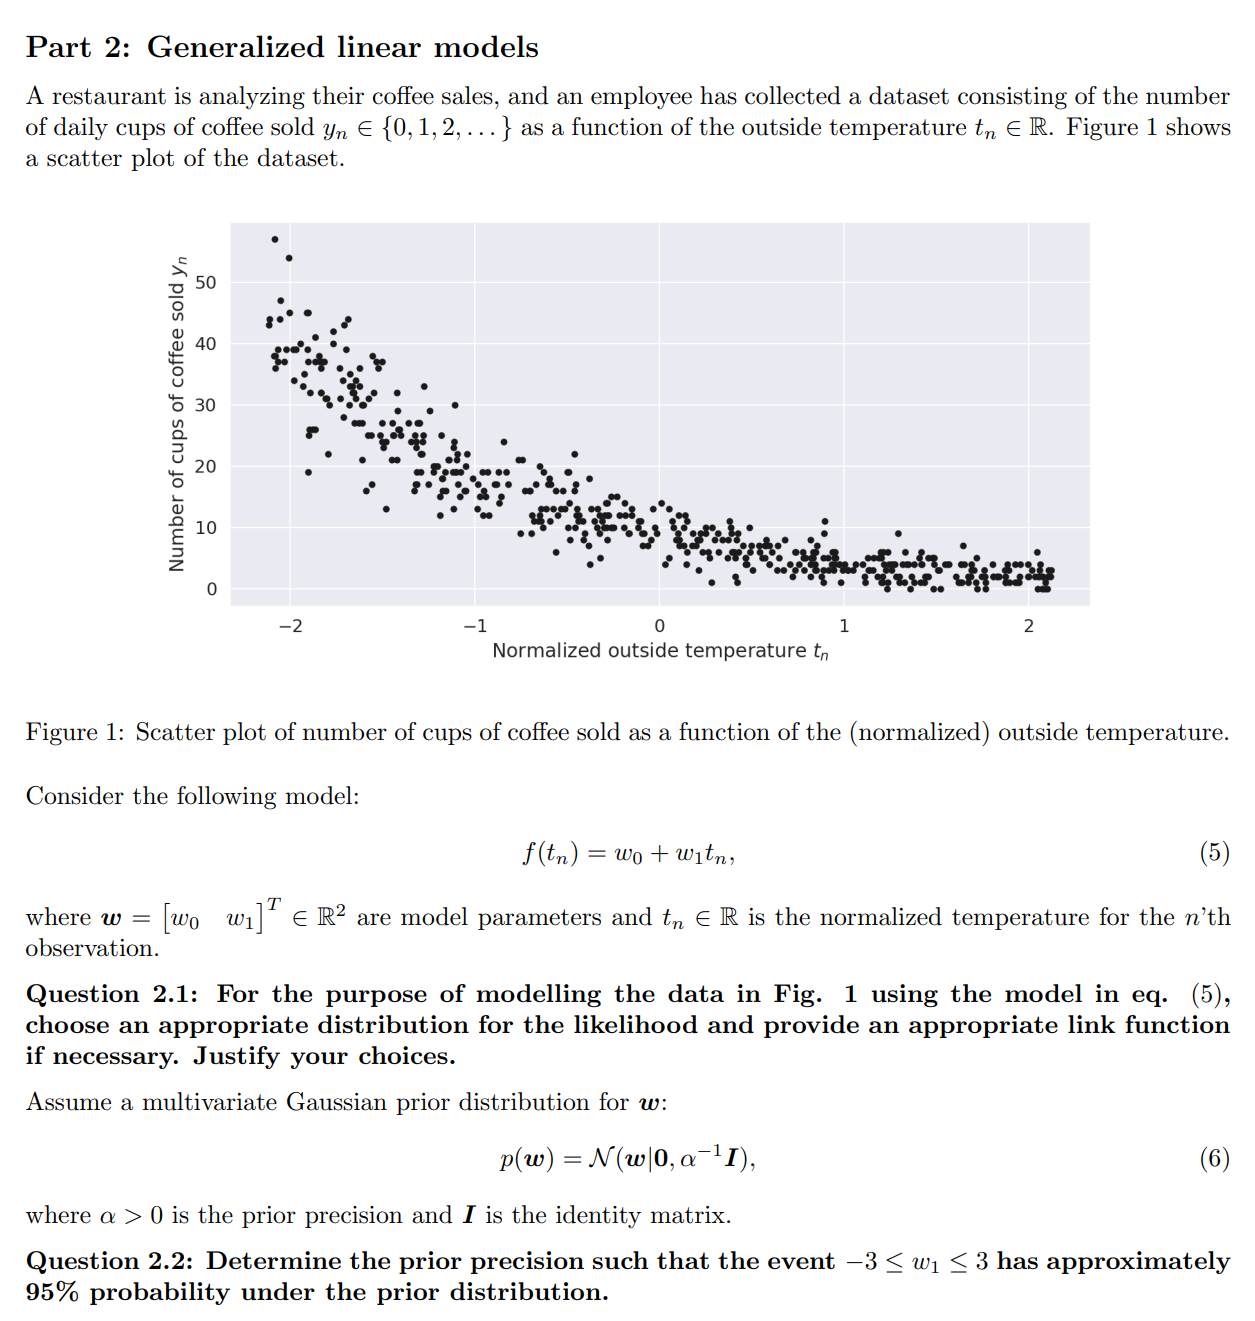

## 2.1

The endogenous variable (number of daily cups of coffee sold) is a count, so Poisson distribution is appropriate for the likelihood. This has the property that it is never negative, parameterised by its mean, and is well-approximated by a Gaussian for even moderately large counts.

The link function relates the mean of the linear model to the mean of the data.

Since the data is strictly non-negative, we propose a link function $g(x) = \log(x)$, or equivalently an inverse link $g^{-1}(x) = \exp(x)$

In [ ]:
alpha = 0.43
dist = stats.Normal(mu=0, sigma=jnp.sqrt(1 / alpha))

dist.cdf(-3, 3)

# Symmetry so can use icdf
# alpha_target = dist.icdf(0.95/2)

# Validate:
# dist_target = stats.Normal(mu=0, sigma=jnp.sqrt(1 / alpha_target))
# dist_target.cdf(-3, 3)
# alpha_target

np.float64(0.950843483348787)

Thus we pick $α=0.43$ which gives a $≈0.95084\%$ probability of the event $-3<w_1<3$.

See paper hand-in for a bit more math and theory.

# 3

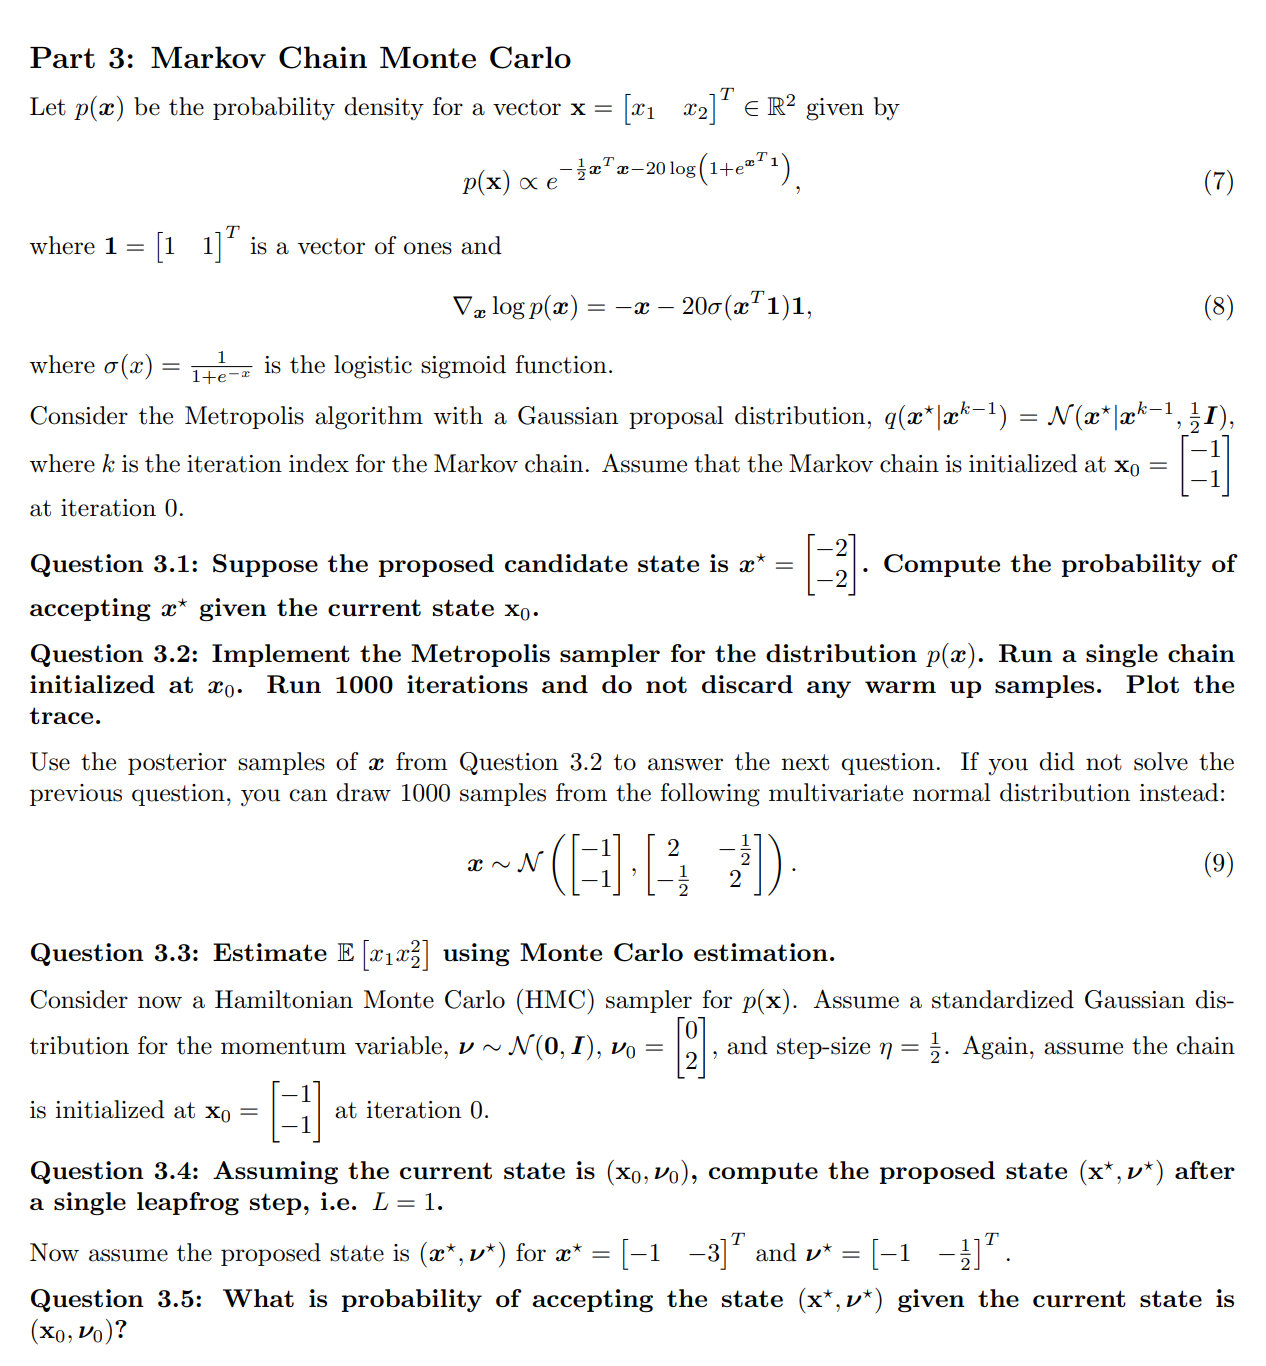

In [151]:
def log_p(x):
    term1 = -1 / 2 * (x.T @ x)
    term2 = -20 * jnp.log(1 + jnp.exp(x.T @ jnp.ones(2)))

    return term1 + term2


def p(x):
    return jnp.exp(log_p(x))


x_0 = jnp.array([-1, -1])
x_star = jnp.array([-2, -2])

p_0 = p(x_0)
p_star = p(x_star)

ratio = p_star / p_0

A_k = min(1, ratio)


print(f"{p_0=:.3f}\n{p_star=:.3f}\n{ratio=:.3f}\n{A_k=}")

p_0=0.029
p_star=0.013
ratio=0.438
A_k=Array(0.4384811, dtype=float32)


## 3.2

In [166]:
## From ex8


def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):
    """Runs a Metropolis-Hastings sampler

    Arguments:
    log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
    num_params:         number of parameters of the joint distribution (integer)
    tau:                standard deviation of the Gaussian proposal distribution (positive real)
    num_iter:           number of iterations (integer)
    theta_init:         vector of initial parameters (np.array with shape (num_params) or None)
    seed:               seed (integer)

    returns
    thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """

    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))

    # prepare lists
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)

    for k in range(num_iter):
        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau * random.normal(key_proposal, shape=(num_params,))

        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))

        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)

        thetas.append(theta_next)

    print("Acceptance ratio: %3.2f" % jnp.mean(jnp.array(accepts)))

    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter + 1, num_params), (
        f"The shape of thetas was expected to be ({num_iter + 1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code."
    )
    return thetas, accepts


# run sampler
num_params = 2
tau = 1 / jnp.sqrt(2)
num_iter = 1_000
theta_init = x_0
thetas, accepts = metropolis(
    log_target=log_p, num_params=2, tau=tau, num_iter=num_iter, theta_init=theta_init
)

# estimate the mean and variance of p_target and relative errors
mean_thetas, var_thetas = jnp.mean(thetas), jnp.var(thetas)
rel_err_mean, rel_err_var = (mean_thetas - 1.0) / 1.0, (var_thetas - 3.0) / 3.0

print("\nSanity check: Running the sampling with N(x|1, 3) as target")
print(f"Estimated mean:\t\t{mean_thetas:3.2f} (rel. err: {rel_err_mean:3.2f})")
print(f"Estimated variance:\t{var_thetas:3.2f} (rel. err: {rel_err_var:3.2f})\n")

if np.abs(rel_err_mean) < 0.05 and np.abs(rel_err_var) < 0.05:
    print(
        "The relative errors for the first two central moments are less than 5%. Everything looks ok."
    )
else:
    print(
        "The relative errors for the first two central moments are larger than 5%. If this happens consistently, something is likely wrong. Check your implementation"
    )

Acceptance ratio: 0.57

Sanity check: Running the sampling with N(x|1, 3) as target
Estimated mean:		-1.45 (rel. err: -2.45)
Estimated variance:	0.72 (rel. err: -0.76)

The relative errors for the first two central moments are larger than 5%. If this happens consistently, something is likely wrong. Check your implementation


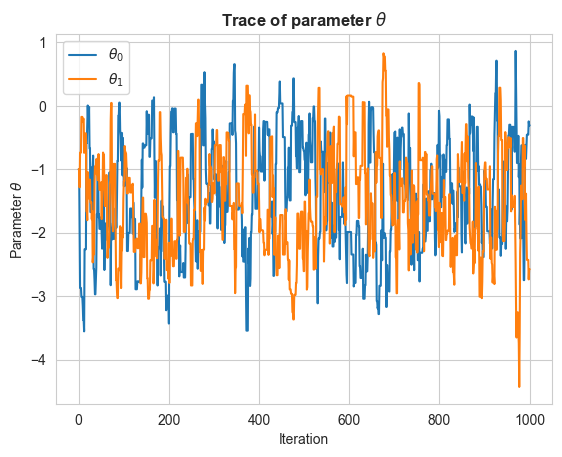

In [163]:
fig, ax = plt.subplots()

ax.plot(thetas[:, 0], label="$θ_0$")
ax.plot(thetas[:, 1], label="$θ_1$")
ax.set_xlabel("Iteration")
ax.set_ylabel("Parameter $\\theta$")
ax.set_title("Trace of parameter $\\theta$", fontweight="bold")
ax.legend()

## 3.3

By Markov property we can use any two contiguous pairs from samples.

NOTE: We should only use **accepted** samples in our posterior estimate, otherwise detailed balance would not matter.

In [171]:
# Note: should we not only use accepted samples for this?
thetas_accepted = thetas[1:][np.array(accepts) == 1]
thetas_accepted.shape

(566, 2)

In [177]:
x1s = thetas_accepted[:, 0]
x2s = thetas_accepted[:, 1]

samples = x1s * (x2s**2)

samples.mean()

Array(-3.3686225, dtype=float32)

## 3.4

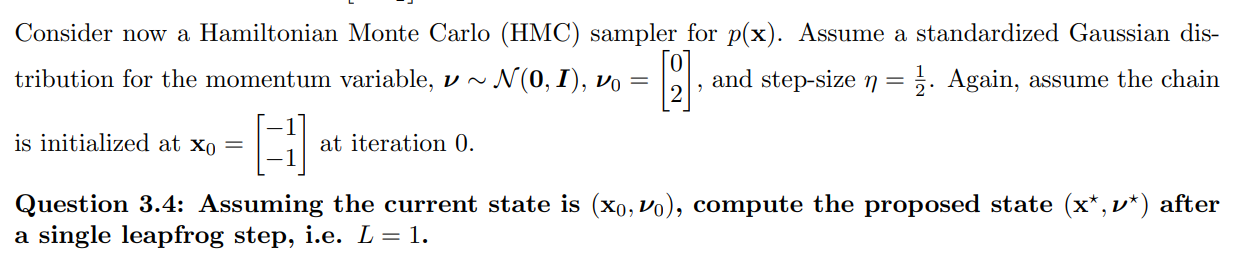

In [181]:
nu_0 = jnp.array([0, 2])
eta = 1 / 2
x_0 = x_0

sigmoid = lambda x: 1 / (1 + jnp.exp(-x))


def grad_log_p(x):
    I = jnp.ones(len(x))

    term1 = -x
    term2 = -20 * sigmoid(x.T @ I) * I
    return term1 + term2


nu_half = nu_0 - eta / 2 * grad_log_p(x_0)
x_1 = x_0 + eta * nu_half
nu_1 = nu_half - eta / 2 * grad_log_p(x_1)

print(f"(x_*, ν_*) = ({x_1}, {nu_1})")

(x_*, ν_*) = ([-0.8269927   0.17300725], [1.8497264 4.099726 ])


## 3.5

See paper also

In [204]:
def E(x):
    return -jnp.log(p(x))


def K(nu):
    # Note: nu is standard normal distributed
    p_nu = multivariate_normal.pdf(nu)
    return -jnp.sum(jnp.log(p_nu))


def H(x, nu):
    print(K(nu))
    return E(x) + K(nu)


x_0 = jnp.array([-1, -1])
x_star = jnp.array([-1, -3])

nu_0 = jnp.array([0, 2])
nu_star = jnp.array([-1, -1 / 2])

H_0 = H(x_0, nu_0)
H_star = H(x_star, nu_star)

prop_candidate = jnp.exp(-H_star + H_0)

a_k = min(1, prop_candidate)
print(f"{prop_candidate=}")

print(f"Acceptance probability: {a_k:.4f}")


3.8378768
2.462877
prop_candidate=Array(0.63798624, dtype=float32)
Acceptance probability: 0.6380


# 4

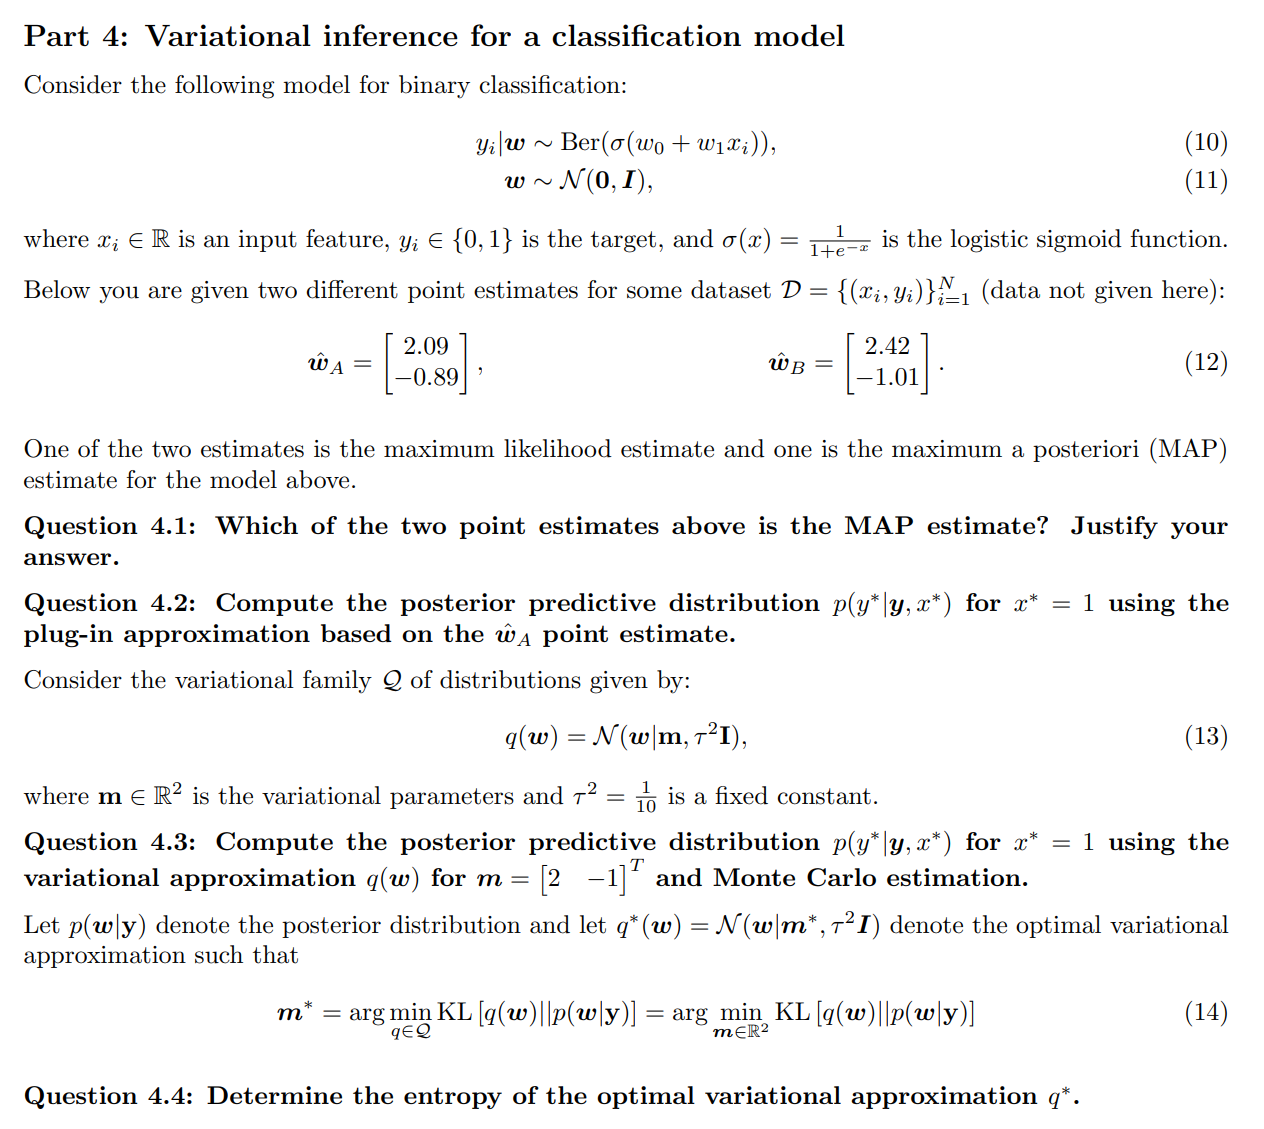

## 4.1

MAP estimate incorporates knowledge of prior, thus acting as a regulariser that biases towards the prior distribution.

Here the prior distribution is the standard normal distribution, which for the two estimates would have biased _towards_ the mean (zero vector).

Thus the estimate with the lowest norm is the MAP estimate, i.e.:

Estimate A ($w_A$) is the MAP estimate, by eliminiation estimate B ($w_B$) is then the maximum likelihood estimate (MLE).

## 4.2

See paper for answer.

In [211]:
w_A = jnp.array([2.09, -0.89])

x_star = 1
sig_arg = w_A[0] + w_A[1] * x_star
ber_arg = sigmoid(sig_arg)

ber_arg

Array(0.7685248, dtype=float32)

## 4.3

This is mean-field variational family, we can reuse code from exercise11.

Never mind, this is actually just about Monte Carlo since we are given the particular 'member' of the family, $q$.

Recall:

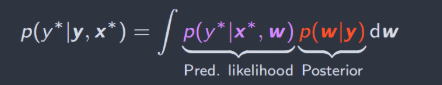

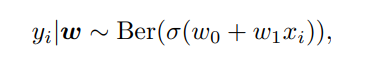

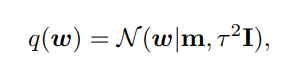

In [ ]:
# We just do simple Monte Carlo estimation with ancestral sampling


tau_sq = 1 / 10
m = jnp.array([2, -1])

N = 10000
w_samples = multivariate_normal.rvs(mean=m, cov=jnp.identity(2) * tau_sq, size=N)
x_star = 1
phi_star = jnp.array([1, x_star])
mu_samples = sigmoid(phi_star @ w_samples.T)
y_star_samples = stats.bernoulli.rvs(
    mu_samples,
)

y_star_mean = y_star_samples.mean()
y_star_mean

np.float64(0.7258)

# 5

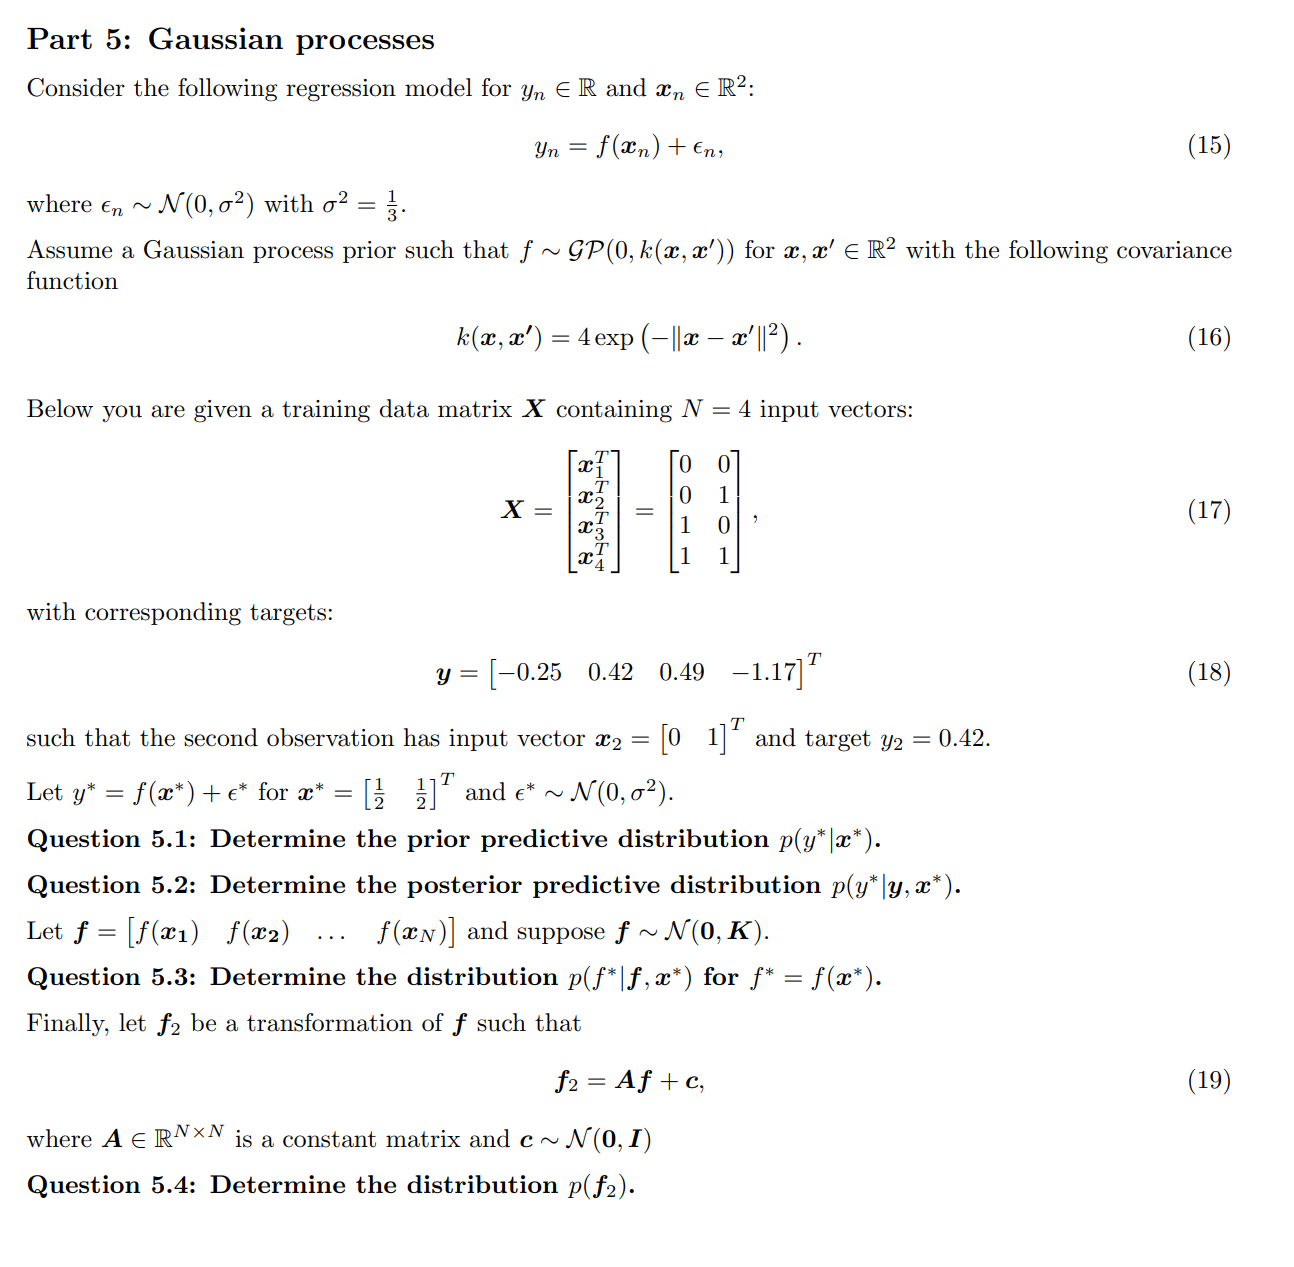

In [234]:
x1 = jnp.array([0, 0])
x2 = jnp.array([0, 1])
x3 = jnp.array([1, 0])
x4 = jnp.array([1, 1])

X = jnp.stack([x1, x2, x3, x4])
X


def k(x_a, x_b):
    return 4 * jnp.exp(-(jnp.linalg.norm(x_a - x_b) ** 2))


Out of time :(